In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def co2_model(year):
    if year <= 1950:
        return 296.0 + 0.30 * (year - 1900)
    elif 1950 < year <= 2000:
        return 311.0 + 1.16 * (year - 1950)
    else:
        t = year - 2000
        return 369.0 + 1.85 * t + 0.018 * (t**2)

In [3]:
def calculate_depth(start_year, end_year, fck, humidity):
    years = np.arange(start_year, end_year + 1)
    depths = [0.0]
    
    # Humidity factor (worst-case scenario occurs around 65% RH)
    rh_factor = 1 - abs(humidity - 65) / 100.0
    
    # Constant adjusted for the 124-year visual scale
    constant = 550.0  
    
    current_depth_squared = 0.0
    for year in years[1:]:
        co2_pct = co2_model(year) / 1e4
        k_year = constant * rh_factor * np.sqrt(co2_pct) / fck
        
        # Accumulating the advance
        current_depth_squared += k_year**2
        depths.append(np.sqrt(current_depth_squared))
        
    return years, depths

In [4]:
start_year = 1900
end_year = 2150
concrete_cover = 30 # Warning line at 30mm

In [5]:
#Chart Configurations
width_cm = 8
height_cm = 8
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

label_size = 12
axis_size = 12
label_color = 'black'

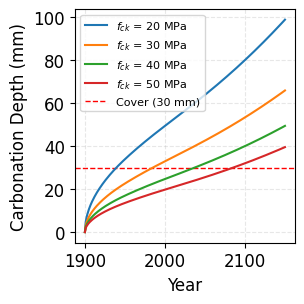

In [10]:
#Fck plotting
plt.figure(figsize=(width_in, height_in))
fck_list = [20, 30, 40, 50]
fixed_humidity = 65

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, fck in enumerate(fck_list):
    years, prof = calculate_depth(start_year, end_year, fck, fixed_humidity)
    plt.plot(years, prof, linewidth=1.5, color=colors[i], label=f'$f_{{ck}}$ = {fck} MPa', zorder=2)

plt.axhline(y=concrete_cover, color='red', linestyle='--', linewidth=1.0, label='Cover (30 mm)', zorder=1)

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel('Year', fontsize=label_size, color=label_color)
plt.ylabel('Carbonation Depth (mm)', fontsize=label_size, color=label_color)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.legend(fontsize=8, loc='upper left')

# Salva os limites dos eixos na memória
xlim_padrao = plt.gca().get_xlim()
ylim_padrao = plt.gca().get_ylim()

plt.savefig('z_graph_1900_fck.png', dpi=600)
plt.show()

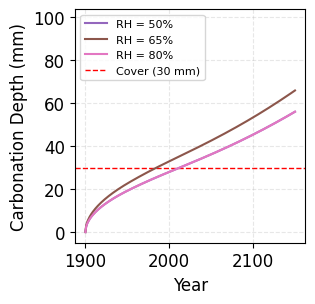

In [11]:
#CO2 plotting
plt.figure(figsize=(width_in, height_in))
fixed_fck = 30
rh_list = [50, 65, 80]
colors_rh = ['#9467bd', '#8c564b', '#e377c2']

for i, rh in enumerate(rh_list):
    years, prof = calculate_depth(start_year, end_year, fixed_fck, rh)
    plt.plot(years, prof, linewidth=1.5, color=colors_rh[i], label=f'RH = {rh}%', zorder=2)

plt.axhline(y=concrete_cover, color='red', linestyle='--', linewidth=1.0, label='Cover (30 mm)', zorder=1)

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel('Year', fontsize=label_size, color=label_color)
plt.ylabel('Carbonation Depth (mm)', fontsize=label_size, color=label_color)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.legend(fontsize=8, loc='upper left')

# Aplica a mesma escala do gráfico anterior
plt.xlim(xlim_padrao)
plt.ylim(ylim_padrao)

plt.savefig('z_graph_1900_h.png', dpi=600)
plt.show()

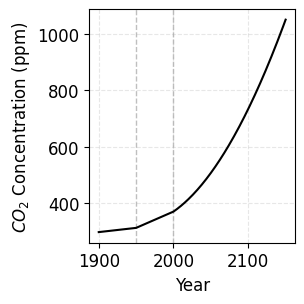

In [8]:
#CO2 concentration plotting
years_co2 = np.arange(start_year, end_year + 1)
co2_ppm = [co2_model(y) for y in years_co2]

plt.figure(figsize=(width_in, height_in))
plt.plot(years_co2, co2_ppm, color='black', linewidth=1.5, label='$CO_2$ Model', zorder=2)

# Demarcation lines
plt.axvline(x=1950, color='gray', linestyle='--', linewidth=1.0, alpha=0.5, zorder=1)
plt.axvline(x=2000, color='gray', linestyle='--', linewidth=1.0, alpha=0.5, zorder=1)

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel('Year', fontsize=label_size, color=label_color)
plt.ylabel('$CO_2$ Concentration (ppm)', fontsize=label_size, color=label_color)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('z_graph_1900_co2.png', dpi=600)
plt.show()